# Parameter selection example - PICO

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from parameter_selection_toolbox_v2 import *

# Settings

In [3]:
# Directories
figure_dir = 'figures'
data_path="/media/NAS2/ISMIP7/share_with_modellers"
ensemble_path="/media/NAS2/pism_out/"

# Constants
yearlen = 365.14*24*60*60 # seconds per year
ice_density = 918 # kg/m3
reso=8000 # m model resolution used for melt parameterisation [m]


# parameterisation ensemble table 
p1_name = 'ocean.pico.overturning_coefficent'
p2_name = 'ocean.pico.heat_exchange_coefficent'

pism_present_day_ensemble = "pism_16_ismip7_picotest_zhou_initmip8km"
pism_mathiot_cold_ensemble = "pism_16_ismip7_picotest_Mathiot_cold_initmip8km"
pism_mathiot_warm_ensemble = "pism_16_ismip7_picotest_Mathiot_warm_initmip8km"

pism_timmermann_cold_ensemble = "pism_16_ismip7_picotest_Timmermann_cold_initmip8km"
pism_timmermann_warm_ensemble = "pism_16_ismip7_picotest_Timmermann_warm_initmip8km"

ensemble_table = pd.read_csv('./'+pism_present_day_ensemble+'.txt',
                                 sep=r'\s+',index_col=0)
ensemble_table

,ocean.pico.overturning_coefficent,ocean.pico.heat_exchange_coefficent
hash,,
117638c5,10000.0,0.000001
61bc631f,10000.0,0.000005
b7ba74fd,10000.0,0.000010
6f6b7091,10000.0,0.000015
49c075df,10000.0,0.000020
...,...,...
ccd1fc05,20000000.0,0.000045
21eb55f8,20000000.0,0.000050
69a82bbf,20000000.0,0.000075


# Load data

In [4]:
# Load ensembles

pd_ensemble = xr.load_dataset('Ensemble_'+pism_present_day_ensemble+'_optimaldeltaT_pm05.nc', drop_variables=['timestamp'])
mathiot_cold_ensemble = xr.load_dataset('Ensemble_'+pism_mathiot_cold_ensemble+'_optimaldeltaT_pm05.nc', drop_variables=['timestamp'])
mathiot_warm_ensemble = xr.load_dataset('Ensemble_'+pism_mathiot_warm_ensemble+'_optimaldeltaT_pm05.nc', drop_variables=['timestamp'])
timmermann_cold_ensemble = xr.load_dataset('Ensemble_'+pism_timmermann_cold_ensemble+'_optimaldeltaT_pm05.nc', drop_variables=['timestamp'])
timmermann_warm_ensemble = xr.load_dataset('Ensemble_'+pism_timmermann_warm_ensemble+'_optimaldeltaT_pm05.nc', drop_variables=['timestamp'])


In [6]:
# combine 

cold_ensemble  = xr.concat([mathiot_cold_ensemble.expand_dims({"model": np.array([0])}), 
                            timmermann_cold_ensemble.expand_dims({"model": np.array([1])})], dim='model')
cold_ensemble = cold_ensemble.assign_coords(model=["mathiot", "timmermann"])

warm_ensemble  = xr.concat([mathiot_warm_ensemble.expand_dims({"model": np.array([0])}), 
                            timmermann_warm_ensemble.expand_dims({"model": np.array([1])})], dim='model')
warm_ensemble = warm_ensemble.assign_coords(model=["mathiot", "timmermann"])


In [5]:
pd_ensemble["invalid"] = np.isnan(pd_ensemble.optimal_deltaT_per_basin.mean('basin', skipna=False))

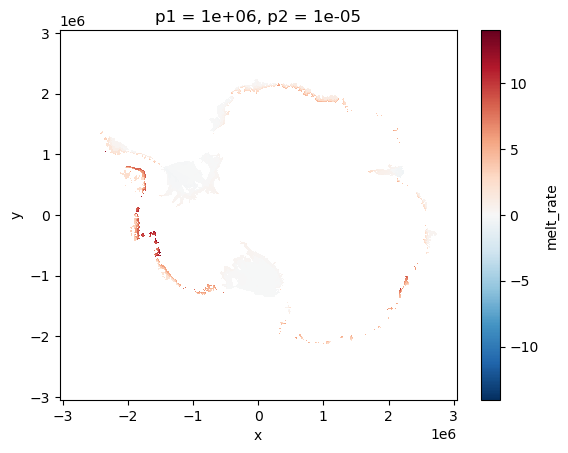

In [7]:
pd_ensemble.sel(p1=1e6,p2=1e-5).melt_rate.plot()

In [8]:
# convert melt rates to kg/m2/a

pd_ensemble['melt_rate'] = pd_ensemble['melt_rate']*ice_density
cold_ensemble['melt_rate'] = cold_ensemble['melt_rate']*ice_density
warm_ensemble['melt_rate'] = warm_ensemble['melt_rate']*ice_density

# Load target data 

In [9]:
MeltDataImbie = pd.read_csv(os.path.join(data_path, 'parameterisations','Melt_Paolo_Err_Adusumilli_imbie2_v2.csv'), index_col=0) # Aggregated per imbier basin

buttressing_target = xr.load_dataset(os.path.join(data_path, 'parameterisations',"melt_target_term2.nc"))

cold_target = xr.load_dataset(os.path.join(data_path, 'parameterisations',"melt_cold_target_term3.nc"))
warm_target = xr.load_dataset(os.path.join(data_path, 'parameterisations',"melt_warm_target_term3.nc"))

t4_obs = xr.load_dataset(os.path.join(data_path, 'parameterisations',"melt_observations_target_term4.nc"))

In [12]:
# Supporting Data

# Load imbie2 basins as used on ISMIP
basins_m = xr.load_dataset(os.path.join(data_path, 'imbie2', "basin_numbers_ismip8km_v2.nc"))
basins_m = basins_m.rename({'basinNumber':'basins'})
nBasins = int(basins_m.basins.max())

# Buttressing Flux Response Numbers, remapped to 8km 
bfrn_m = xr.load_dataset(os.path.join(data_path,'parameterisations',"BFRN_ismip8km_v2.nc"))
nBins = 10

In [13]:
bed_m = xr.load_dataset(os.path.join(data_path, 'topography', 'bedmap3_ismip_8km.nc'))
mask_m = bed_m.floating_frac>0.5

# Optimise

In [10]:
cvt_m = reso**2  / 1e12  # to convert to Gt/a
cvt = 8000**2  / 1e12  # to convert to Gt/a

In [14]:
# Term 1
t1_model, t1_obs_mean, t1_obs_sigma = calculate_term1(
    pd_ensemble,mask_m,basins_m['basins'],nBasins,cvt_m,MeltDataImbie)

In [15]:
# Term 2
t2_model, t2_obs_mean, t2_obs_sigma = calculate_term2(
    pd_ensemble,mask_m,bfrn_m,cvt_m,buttressing_target)

In [16]:
# Term 3
t3_model, t3_obs_mean, t3_obs_sigma = calculate_term3(
    cold_ensemble, warm_ensemble, cold_target, warm_target,
    mask_m,basins_m['basins'])

In [57]:
# Term 4, FIXME needs to be added
# t4_model, t4_obs_mean, t4_obs_sigma = calculate_term4(obs_ensemble, region_label_m, t4_obs, mask_m, cvt_m)
t4_model = t4_obs.melt_rate * 0 # we put a dummy 0 here
t4_model = t4_model.expand_dims(p1 = t1_model.p1.values)
t4_model = t4_model.expand_dims(p2 = t1_model.p2.values)
t4_obs_mean = t4_obs.melt_rate
t4_obs_sigma = t4_obs.melt_rate_uncert

In [58]:
# introduce weights

In [59]:
t1_weights = xr.DataArray(
    t1_obs_mean*0+1,
    dims=["basins"],
    coords={"basins": t1_model.basins.values}
)

# e.g., to sample only FRIS, Ross, Totten and ASE
#t1_weights = t1_weights.where( (t1_weights.basins==9) | 
#                               (t1_weights.basins==14) | 
#                               (t1_weights.basins==7) |
#                               (t1_weights.basins==4), 0)
#t1_weights = t1_weights *0

In [60]:
# Buttressing Flux Response Numbers, remapped to 8km 
bfrn = xr.load_dataset(os.path.join(data_path, 'parameterisations',"BFRN_ismip8km_v2.nc"))

t2_weight = (bfrn['BFRN_medians'] / bfrn['BFRN_median']).values

t2_weights = xr.DataArray(
    t2_weight,
    dims=["BFRN_bins"],
    coords={"BFRN_bins": t2_obs_mean.BFRN_bins.values}
)



In [61]:
weights_data = np.ones(t3_model.isel(p1=0,p2=0).shape) 

t3_weights = xr.DataArray(
    weights_data,
    dims=["model", "basins"],
    coords={"model": t3_model.model.values,
            "basins": t3_model.basins.values}
)

# NOW test whatever weights you want to, for example:
#t3_weights = t3_weights.where(t3_weights.model == "timmermann", other=0)
# sample only FRIS, Ross, and Totten, ASE
#t3_weights = t3_weights.where( (t1_weights.basins==9) | 
#                               (t1_weights.basins==14) | 
#                               (t1_weights.basins==7) |
#                               (t1_weights.basins==4), other=0)

#t3_weights = t3_weights.where( (t1_weights.basins==9) | 
#                               (t1_weights.basins==4), other=0)

#t3_weights = t3_weights *0

In [62]:
# introduce weights, shape of region, years

weights_data = np.transpose(np.ones(t4_obs.melt_rate.shape))

t4_weights = xr.DataArray(
    weights_data*0,
    dims=["year", "region"],
    coords={"year": t4_obs.year.values,
            "region": t4_obs.region.values}
)

# FIXME select here: only PIG or Dotson, or certain years!

#t4_weights = t4_weights.where(t4_weights.region == "dotson", other=0)
#t4_weights = t4_weights.where(t4_weights.region == "pig", other=0)
# where both datasets have data
#t4_weights = t4_weights.where( (t4_weights.year ==2007) | (t4_weights.year==2009) |  (t4_weights.year==2012) |(t4_weights.year==2014) |
#                         (t4_weights.year==2016) ,other=0)
# single year
#t4_weights = t4_weights.where( (t4_weights.year ==2009)  ,other=0)

#t4_weights

In [68]:
sample_size=10000


min_p1, min_p2 = calculate_objective_function(
    sample_size,
    reso,
    t1_model, t1_obs_mean, t1_obs_sigma,t1_weights,
    t2_model, t2_obs_mean, t2_obs_sigma,t2_weights,
    t3_model, t3_obs_mean, t3_obs_sigma,t3_weights,
    t4_model, t4_obs_mean, t4_obs_sigma,t4_weights)

# Analyse parameter distribution

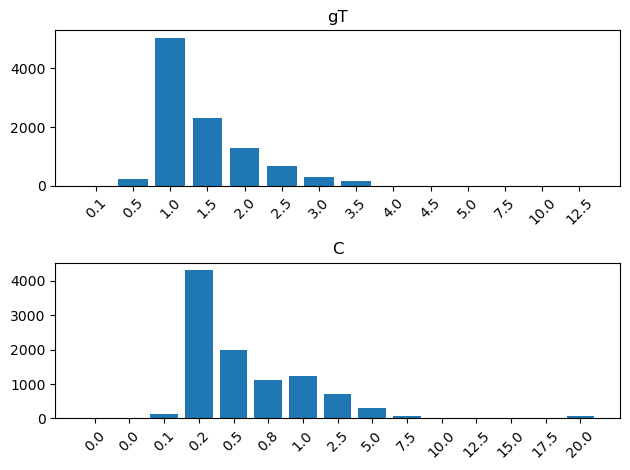

In [73]:
fig,axes = plt.subplots(2,1, sharex=False, sharey=False)
ax = axes.flatten()[0]

bin_edges = np.array( np.append(pd_ensemble.p2.values[0]*0.5, pd_ensemble.p2.values+1e-7) )
counts_p1, _ = np.histogram(np.array(min_p2), bins= bin_edges)
positions = np.arange(len(counts_p1))
ax.bar(positions, counts_p1, width=0.8)
labels = np.round(pd_ensemble.p2.values*1e5, 1)
ax.set_xticks(positions, labels, rotation=45)
ax.set_title('gT')

ax = axes.flatten()[1]
bin_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+0.001e6) )
counts_p2, _ = np.histogram(np.array(min_p1), bins= bin_edges)
positions = np.arange(len(counts_p2))
ax.bar(positions, counts_p2, width=0.8)
labels = np.round(pd_ensemble.p1.values/1e6, 1)
ax.set_xticks(positions, labels, rotation=45)
ax.set_title('C')
plt.tight_layout()

#plt.savefig(os.path.join(figure_dir,pism_present_day_ensemble+'_Hists_Sample'+str(sample_size)+'.png'))

<Figure size 640x480 with 0 Axes>

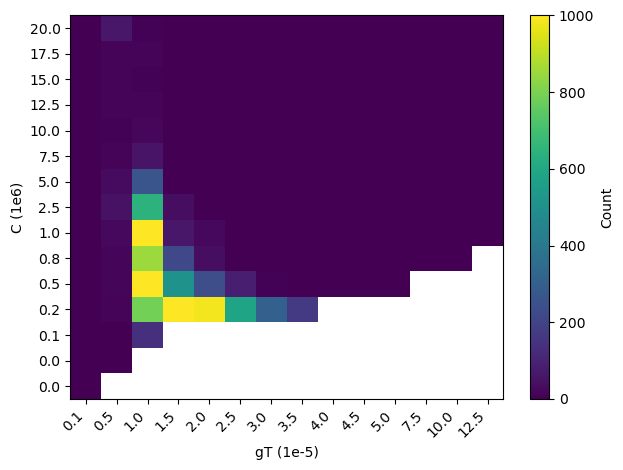

In [186]:
fig,axes = plt.subplots(1,1, sharex=False, sharey=False)
ax = axes

x_edges = np.array( np.append(pd_ensemble.p2.values[0]*0.5, pd_ensemble.p2.values+1e-7) )
y_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+0.001e6) )
counts, _, _ = np.histogram2d(min_p2,np.array(min_p1), bins=[x_edges, y_edges])
plt.clf()

fig, ax = plt.subplots()

counts_masked = np.ma.masked_where(pd_ensemble.invalid.values==True, counts.T)

im = ax.pcolormesh(np.arange(len(x_edges)), np.arange(len(y_edges)), 
                    #counts.T, cmap='viridis', shading='auto', vmin=0 #, vmax=1000
                    counts_masked, cmap='viridis', shading='auto', vmin=0 , vmax=1000
                  )

y_labels = np.round(pd_ensemble.p1.values/1e6, 1)
x_labels = np.round(pd_ensemble.p2.values*1e5, 1)

# Set tick positions and labels
ax.set_xticks(np.arange(len(x_labels))+0.5)
ax.set_yticks(np.arange(len(y_labels))+0.5)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_yticklabels(y_labels)

ax.set_ylabel("C (1e6)")
ax.set_xlabel("gT (1e-5)")
plt.colorbar(im, label='Count')
plt.tight_layout()

#plt.savefig(os.path.join(figure_dir,pism_present_day_ensemble+'_Hist2D_Sample'+str(sample_size)+'_all.png'))    

# Select parameters

In [199]:
# Find min, max, 5th, 95th, and modes

print('Start exploring global modes:')

from scipy.ndimage import gaussian_filter, maximum_filter

smooth = gaussian_filter(counts_masked, sigma=1)

local_max = (smooth == maximum_filter(smooth, size=2))
local_max &= smooth > 100  # optional

mode_indices = np.argwhere(local_max)
modes = np.array([
    [pd_ensemble.p1.values[i], pd_ensemble.p2.values[j]]
    for i,j in mode_indices
])
print(modes)



print('\n\nIndividual stats on C, gT')
print('median: C=', np.median(np.array(min_p1))/1e6, 'x1e6 gT=', np.median(np.array(min_p2)))
print('mode:   C=', pd_ensemble.p1.values[np.argmax(counts_p1) ]/1e6, 'x1e6 gT=', pd_ensemble.p2.values[np.argmax(counts_p2) ])


print('Uncertainty bounds:')
print('5th:    C=', np.percentile(np.array(min_p1), 5)/1e6, 'x1e6 gT=', np.percentile(np.array(min_p2), 5))
print('95th:   C=', np.percentile(np.array(min_p1), 95)/1e6, 'x1e6 gT=', np.percentile(np.array(min_p2), 95))


print('Further options for uncertainty exploration:')
print('min:    C=', np.min(np.array(min_p1))/1e6, 'x1e6 gT=', np.min(np.array(min_p2)))
print('1st:    C=', np.percentile(np.array(min_p1), 1)/1e6, 'x1e6 gT=', np.percentile(np.array(min_p2), 1))
print('99th:   C=', np.percentile(np.array(min_p1), 99)/1e6, 'x1e6 gT=', np.percentile(np.array(min_p2), 99))
print('max:    C=', np.max(np.array(min_p1))/1e6, 'x1e6 gT=', np.max(np.array(min_p2)))

vals = [np.min(np.array(min_p1)), np.percentile(np.array(min_p1), 1), 
        np.percentile(np.array(min_p1), 5), np.median(np.array(min_p1)), 
        np.percentile(np.array(min_p1), 95), np.percentile(np.array(min_p1), 99),
        np.max(np.array(min_p1))
       ]
labs = ['min', '1st', '5th', '50th', '95th', '99th', 'max']





Start exploring global modes:
[[1.0e+05 1.0e-05]
 [1.0e+05 1.5e-05]
 [2.5e+05 5.0e-06]
 [2.5e+05 1.0e-05]
 [2.5e+05 1.5e-05]
 [5.0e+05 5.0e-06]
 [5.0e+05 1.0e-05]]


Individual stats on C, gT
median: C= 0.5 x1e6 gT= 1e-05
mode:   C= 0.1 x1e6 gT= 1.5e-05
Uncertainty bounds:
5th:    C= 0.25 x1e6 gT= 1e-05
95th:   C= 2.624999999998181 x1e6 gT= 2.5e-05
Further options for uncertainty exploration:
min:    C= 0.05 x1e6 gT= 5e-06
1st:    C= 0.1 x1e6 gT= 5e-06
99th:   C= 12.5 x1e6 gT= 3.5e-05
max:    C= 20.0 x1e6 gT= 3.5e-05


# Analyse parameters

In [201]:
C = 0.25e6
gT = 1.5e-5

In [202]:
result_ds = pd_ensemble.sel(p1=C, p2=gT)

Text(0.5, 1.0, 'Present-day melt rates')

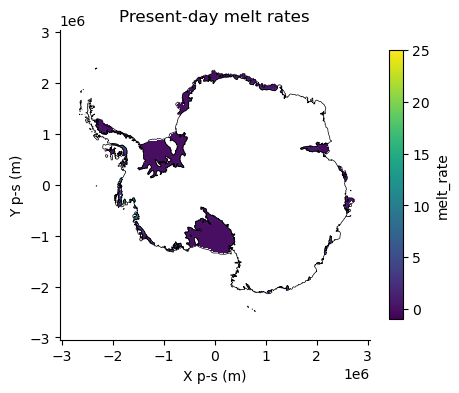

In [204]:
plt.figure(figsize=(5,5))

(result_ds.melt_rate/ice_density).plot( vmin=-1, vmax=25, cmap='viridis',cbar_kwargs={'shrink': 0.7} )
ax = plt.gca()
ax.set_aspect('equal')
ax.set_xlabel('X p-s (m)')
ax.set_ylabel('Y p-s (m)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.contour(result_ds.x, result_ds.y, bed_m.ocean_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.contour(result_ds.x, result_ds.y, bed_m.floating_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.title('Present-day melt rates')

#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_pdmelt.png'))  

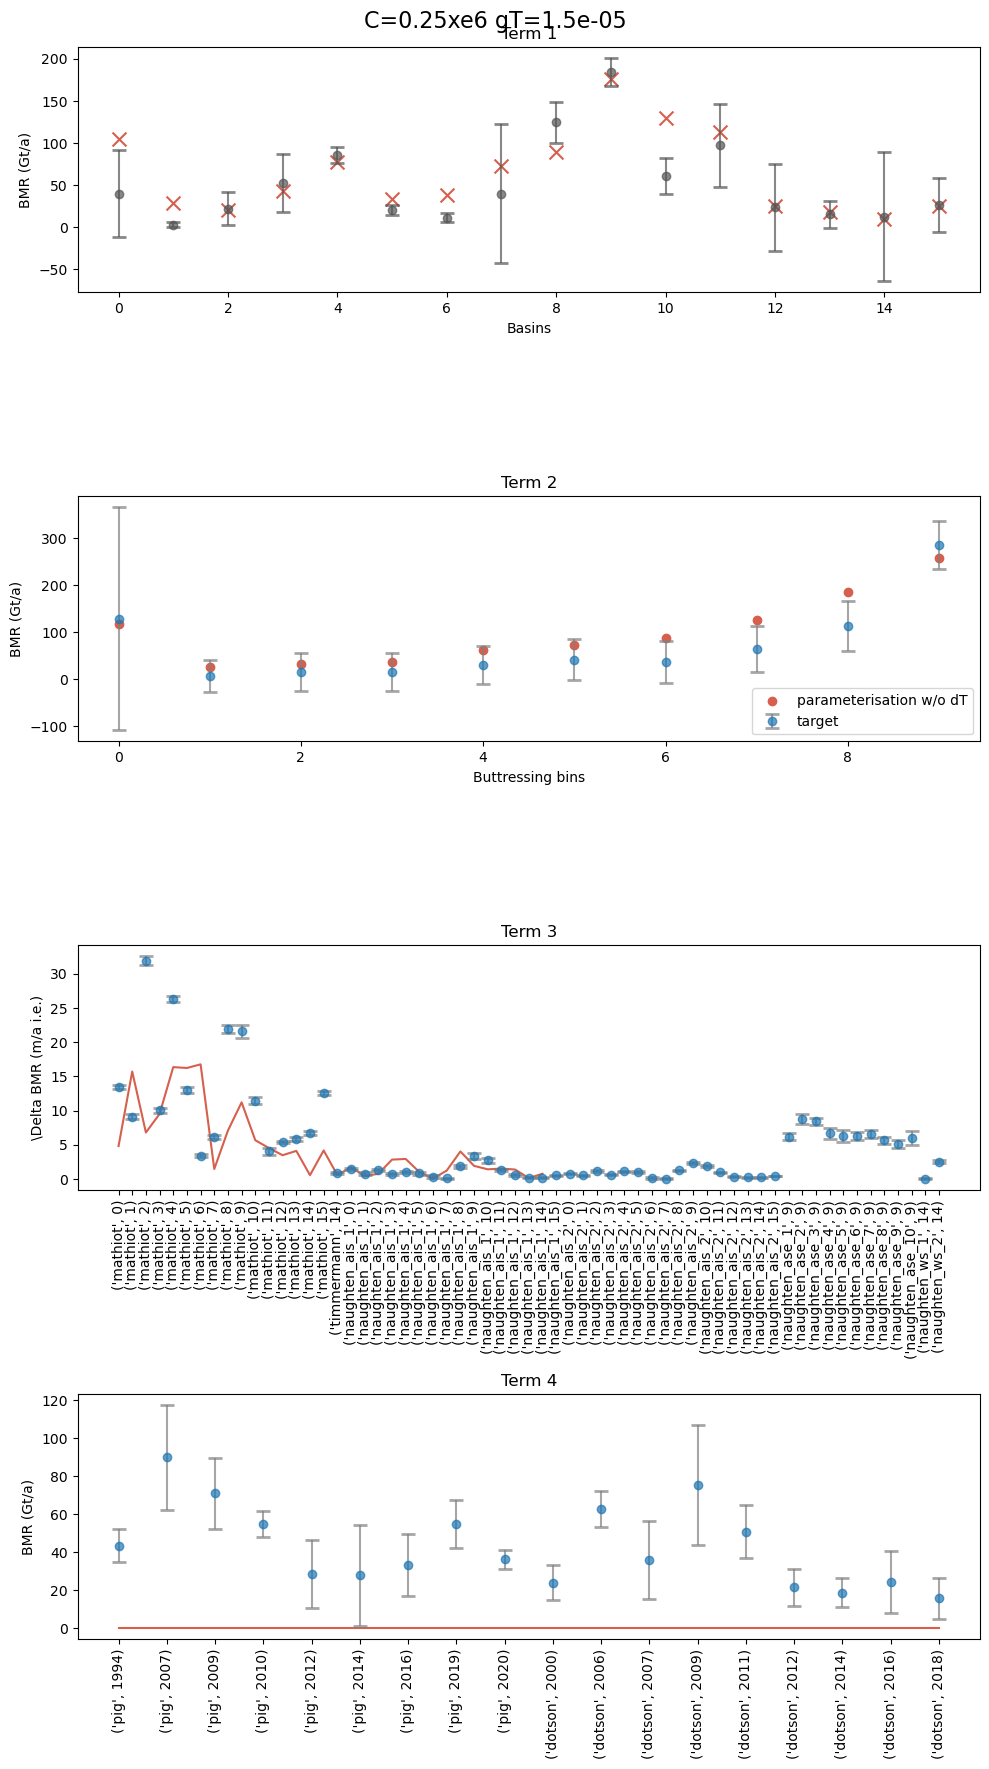

In [206]:
# Basic 2x2 grid

cvt = 8000**2  / 1e12  # to convert to Gt/a
cvt_m = reso**2  / 1e12  # to convert to Gt/a

fig, axes = plt.subplots(4, 1, figsize=(10, 18))

color_wocorrection = "#D6604D"
color_wcorrection = "#2166AC"

# TERM 1
ax = axes[0]  

t1_model_ndT, t1_obs_mean_ndT, t1_obs_sigma_ndT = calculate_term1(
    pd_ensemble.sel(p1=C,p2=gT), mask_m, basins_m.basins, nBasins, cvt_m, MeltDataImbie)

#t1_model, t1_obs_mean, t1_obs_sigma = calculate_term1(
#    result_ds, mask_m, basins_m.basins, nBasins, cvt_m, MeltDataImbie)

#ax.plot(range(nBasins+1),t1_model , label='parameterisation', color=color_wcorrection)
ax.scatter(range(nBasins+1),t1_model_ndT , label='parameterisation w/o dT', color=color_wocorrection, marker='x', s=100)
ax.errorbar(range(nBasins+1), t1_obs_mean, xerr=None, yerr=t1_obs_sigma, 
             fmt='o', capsize=5, capthick=2, color="#555555", 
             ecolor="#555555", alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xlabel('Basins')
#plt.text(0,2, 'Modelled average melt = '+str(np.round(np.sum(t2_model).values))+' m/a' )
#plt.text(0,1, 'Observed average melt = '+str(np.round(np.sum(t2_obs_mean).values))+' m/a' )
#ax.legend()
ax.set_title('Term 1')


# TERM 2
ax = axes[1]  
t2_model_ndT, t2_obs_mean, t2_obs_sigma = calculate_term2(
    pd_ensemble.sel(p1=C,p2=gT),mask_m,bfrn_m,cvt_m,buttressing_target)

#t2_model, t2_obs_mean, t2_obs_sigma = calculate_term2(
#    result_ds,mask_m,bfrn_m,cvt_m,buttressing_target)

#ax.plot(range(len(t2_model.BFRN_bins)),t2_model , label='parameterisation', color=color_wcorrection)
ax.scatter(range(len(t2_model.BFRN_bins)),t2_model_ndT , label='parameterisation w/o dT', color=color_wocorrection)
ax.errorbar(range(len(t2_model.BFRN_bins)), t2_obs_mean, xerr=None, yerr=t2_obs_sigma, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xlabel('Buttressing bins')
ax.legend()
ax.set_title('Term 2')


# Term 3
ax = axes[2]  

t3_model_ndT, t3_obs_mean, t3_obs_sigma = calculate_term3(
    cold_ensemble.sel(p1=C,p2=gT), warm_ensemble.sel(p1=C,p2=gT), cold_target, warm_target, mask_m, basins_m.basins)

#t3_model, t3_obs_mean, t3_obs_sigma = calculate_term3(
#    cold_results,warm_results, cold_target, warm_target, mask_m, basins_m.basins)

#t3_stack = t3_model.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')
t3_stack_ndT = t3_model_ndT.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')

#ax.plot(range(len(t3_stack.modelbasin)),
#        t3_stack/ice_density , label='parameterisation', color=color_wcorrection)
ax.plot(range(len(t3_stack_ndT.modelbasin)),
        t3_stack_ndT/ice_density , label='parameterisation w/o dT', color=color_wocorrection)

ax.errorbar(range(len(t3_obs_mean.stack(modelbasin=('model','basins')).dropna(dim='modelbasin').modelbasin)), 
            t3_obs_mean.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')/ice_density, 
            xerr=None, yerr=t3_obs_sigma.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')/ice_density, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('\Delta BMR (m/a i.e.)')
ax.set_xticks(range(len(t3_obs_mean.stack(modelbasin=('model','basins')).dropna(dim='modelbasin').modelbasin)))
ax.set_xticklabels(t3_obs_mean.stack(modelbasin=('model','basins')).dropna(dim='modelbasin').modelbasin.values, rotation=90)
ax.set_title('Term 3')

## Term 4
ax = axes[3] 


#t4_model_ndT, t4_obs_mean, t4_obs_sigma = calculate_term4(
#    obs_ensemble.sel(p1=C,p2=gT), region_label_m, t4_obs, mask_m, cvt_m)

#t4_model, t4_obs_mean, t4_obs_sigma = calculate_term4(
#    obs_results, region_label_m, t4_obs, mask_m, cvt_m)


ds_flat_ndT = t4_model.isel(p1=0,p2=0).stack(region_year=("region", "year")).dropna(dim='region_year')
#ds_flat = t4_model.stack(region_year=("region", "year")).dropna(dim='region_year')


ax.plot(range(len(ds_flat_ndT.region_year)),ds_flat_ndT.values , label='parameterisation w/o dT', color=color_wocorrection)
#ax.plot(range(len(ds_flat.region_year)),ds_flat.values , label='parameterisation', color=color_wcorrection)

ax.errorbar(range(len(ds_flat_ndT.region_year)), 
            t4_obs_mean.stack(region_year=('region','year')).dropna(dim='region_year'), 
            xerr=None, 
            yerr=t4_obs_sigma.stack(region_year=('region','year')).dropna(dim='region_year'),
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xticks(range(len(ds_flat_ndT.region_year)))
ax.set_xticklabels(ds_flat_ndT.region_year.values, rotation=90)
ax.set_title('Term 4')

# Add overall title
fig.suptitle('C='+str(C/1e6)+'xe6 gT='+str(gT), fontsize=16)


plt.tight_layout()
plt.show()

#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_Terms.png'))  